In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

In [2]:
df = pd.read_csv(r"C:\sales\samplesuperstore.csv")  


In [3]:
df.columns = df.columns.str.strip()

print("First 5 rows:\n", df.head())
print("Shape:", df.shape)

First 5 rows:
    Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  US-2023-103800   1/3/2023   1/7/2023  Standard Class    DP-13000   
1       2  US-2023-112326   1/4/2023   1/8/2023  Standard Class    PO-19195   
2       3  US-2023-112326   1/4/2023   1/8/2023  Standard Class    PO-19195   
3       4  US-2023-112326   1/4/2023   1/8/2023  Standard Class    PO-19195   
4       5  US-2023-141817   1/5/2023  1/12/2023  Standard Class    MB-18085   

   Customer Name      Segment Country/Region          City  ... Postal Code  \
0  Darren Powers     Consumer  United States       Houston  ...       77095   
1  Phillina Ober  Home Office  United States    Naperville  ...       60540   
2  Phillina Ober  Home Office  United States    Naperville  ...       60540   
3  Phillina Ober  Home Office  United States    Naperville  ...       60540   
4     Mick Brown     Consumer  United States  Philadelphia  ...       19143   

    Region       Product ID        

In [4]:
print("\nInfo:\n")
print(df.info())

print("\nDescription:\n")
print(df.describe())

print("\nMissing Values:\n")
print(df.isna().sum())



Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 n

In [5]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())


In [6]:
print("\nMean:\n", df[num_cols].mean())
print("\nMedian:\n", df[num_cols].median())
print("\nMode:\n", df[num_cols].mode().iloc[0])
print("\nVariance:\n", df[num_cols].var())
print("\nSkewness:\n", df[num_cols].apply(skew))


Mean:
 Row ID      5097.500000
Sales        228.225854
Quantity       3.791838
Discount       0.155385
Profit        28.673417
dtype: float64

Median:
 Row ID      5097.50
Sales         53.91
Quantity       3.00
Discount       0.20
Profit         8.69
dtype: float64

Mode:
 Row ID       1.00
Sales       12.96
Quantity     2.00
Discount     0.00
Profit       0.00
Name: 0, dtype: float64

Variance:
 Row ID      8.660652e+06
Sales       3.842845e+05
Quantity    4.965396e+00
Discount    4.253848e-02
Profit      5.404003e+04
dtype: float64

Skewness:
 Row ID       0.000000
Sales       12.982015
Quantity     1.268446
Discount     1.687204
Profit       7.603787
dtype: float64


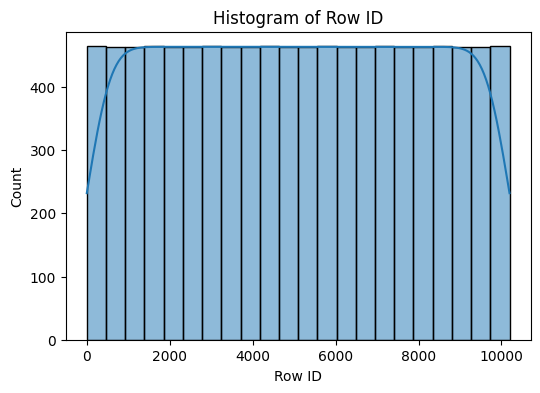

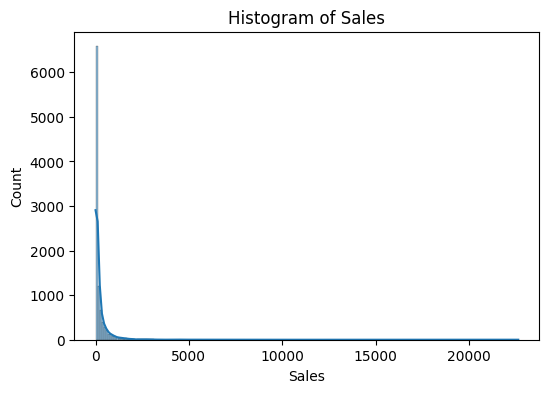

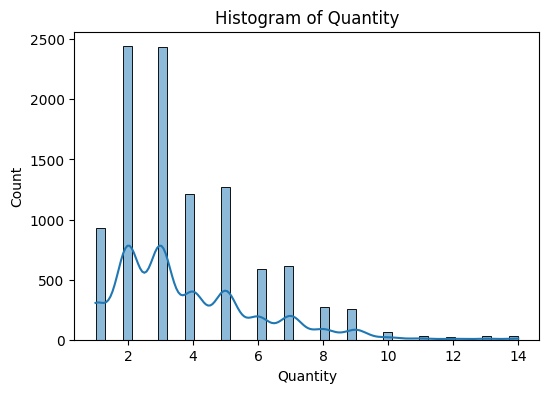

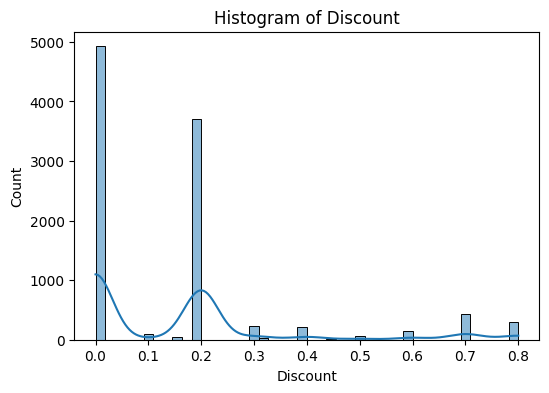

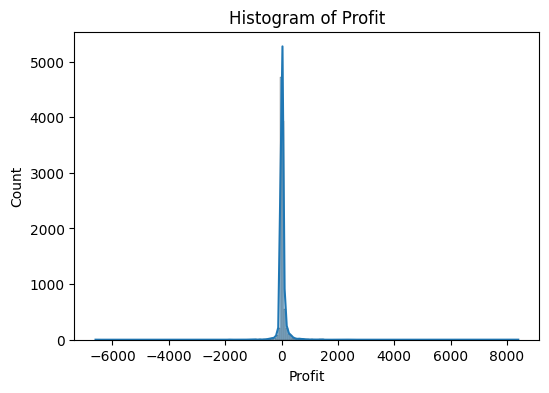

In [7]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

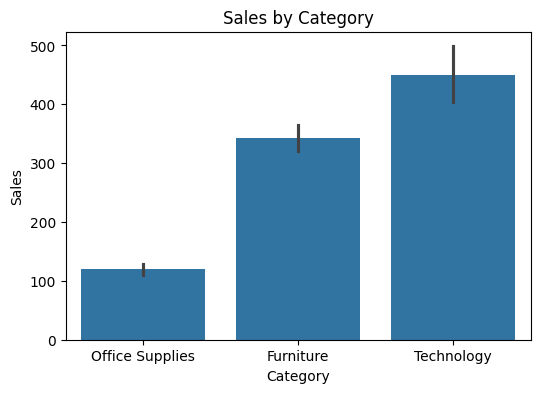

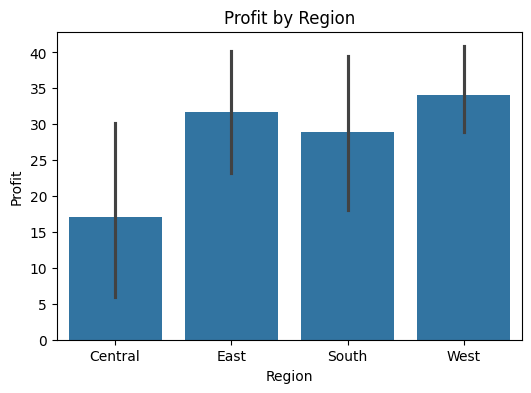

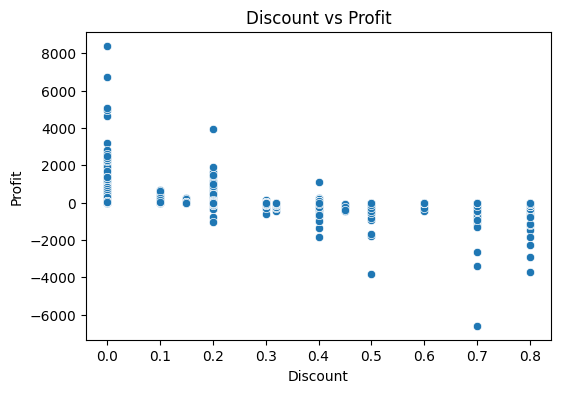

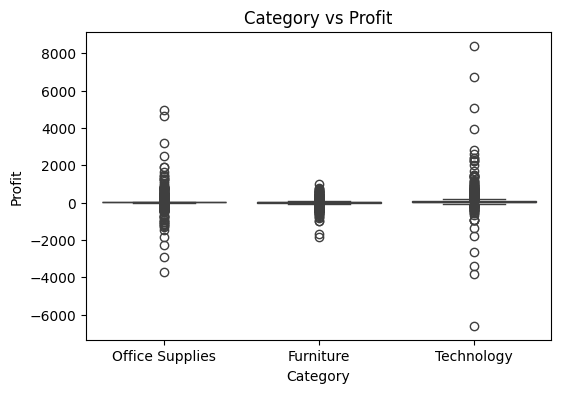

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(x="Category", y="Sales", data=df)
plt.title("Sales by Category")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x="Region", y="Profit", data=df)
plt.title("Profit by Region")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="Discount", y="Profit", data=df)
plt.title("Discount vs Profit")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="Category", y="Profit", data=df)
plt.title("Category vs Profit")
plt.show()

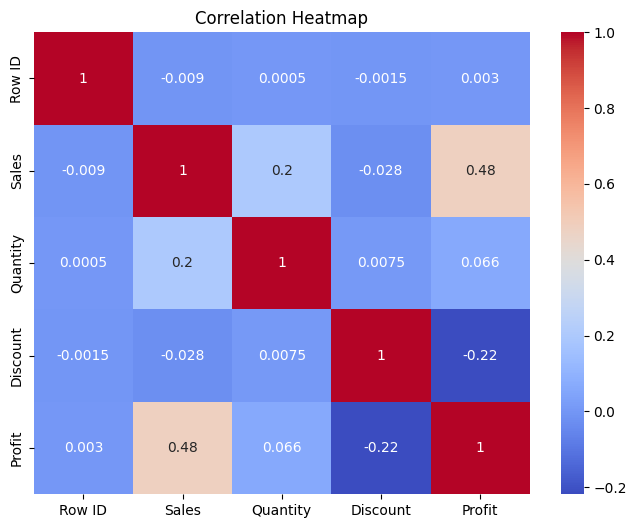

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
top_products = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Profitable Products:\n", top_products)

region_sales = df.groupby("Region")["Sales"].sum()
print("\nSales by Region:\n", region_sales)


Top 10 Profitable Products:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

Sales by Region:
 Region
Ce

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
X = df[["Sales", "Quantity", "Discount"]]
y = df["Profit"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("\nR2 Score:", r2_score(y_test, y_pred))



R2 Score: 0.2207301447798765


In [12]:
from sqlalchemy import create_engine
engine = create_engine("mysql+pymysql://root:@localhost/superstore_db")
df.to_sql("superstore_data", con=engine, if_exists="replace", index=False)
print("\nData stored successfully in MySQL!")


Data stored successfully in MySQL!
